In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# ==========================================
# 1. Data preprocessing
# ==========================================
print("Reading and preparing data...")
df = pd.read_csv('wifi_data_v4_final.csv')
df['true_sample_id'] = (df[['sample_id', 'location']] != df[['sample_id', 'location']].shift()).any(axis=1).cumsum()
pivot_df = df.pivot_table(index=['true_sample_id', 'location'], columns='bssid', values='avg_rssi')
pivot_df = pivot_df.fillna(-100)
final_df = pivot_df.reset_index()
final_df = final_df.rename(columns={'true_sample_id': 'sample_id'})

X = final_df.drop(['sample_id', 'location'], axis=1)
y = final_df['location']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Reading and preparing data...


In [11]:
# ==========================================
# Data Exploration
# ==========================================
total_samples = len(final_df)
print(f"\nData exploration completed: A total of {total_samples} location samples were collected!")

print("Number of samples for each room/location:")
# value_counts() automatically counts the number of samples
# for each location and sorts them in descending order
print(final_df['location'].value_counts())
print("-" * 40 + "\n")


Data exploration completed: A total of 1957 location samples were collected!
Number of samples for each room/location:
location
MSMX 0002        40
MSMX 0003        40
MSMX 0004        40
MSMX 2001        40
MSMX 2003        40
MSMX 2004        40
MSMX 2005        40
MSMX 2006        40
MSMX 2007        40
MSMR 2009        40
MSMR 2010        40
MSMR 2011        40
MSMR 2012        40
MSMR 2014        40
MSMR 2013        40
MSMR 2015        40
MSMR 2016        40
2_Mid_Stair      40
MSMX 3001        40
MSMX 3002        40
MSMX 3003        40
MSMX 3004        40
MSMR 3005        40
MSMR 3006        40
MSMR 3009        40
MSMR 3010        40
MSMR 3011        40
MSMR 3012        40
MSMR 3013        40
MSMR 3014        40
MSMR 3015        40
MSMR 3016        40
2_Lift_Toilet    40
G_Right_Stair    40
2_Right_Stair    40
1_Right_Stair    40
1_Mid_Stair      40
1_Left_Stair     40
1_Lift_Toilet    40
G_Left_Stair     40
G_Mid_Stair      40
MSMR 3008        40
G_Lift_Toilet    40
2_Left_Stai

In [12]:
# ==========================================
# Phase 1: Random Forest AP Selection (Feature Selection)
# ==========================================
print("Phase 1: Awaken Random Forest and begin filtering for the best routers (APs)....")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Obtain the "importance score" for each router.
importances = rf.feature_importances_
feature_names = X.columns

# Sort the routers from most important to least important.
feature_importance_df = pd.DataFrame({'BSSID': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Only retain the top 15 most stable routers (discard spam signals).
TOP_N = 150
top_aps = feature_importance_df.head(TOP_N)['BSSID'].tolist()
print(f"AP screening complete! From {len(feature_names)} routers, the top {TOP_N} strongest routers were selected.")

# Rebuild our training and test sets using the filtered Access Points!
X_train_clean = X_train[top_aps]
X_test_clean = X_test[top_aps]

Phase 1: Awaken Random Forest and begin filtering for the best routers (APs)....
AP screening complete! From 568 routers, the top 150 strongest routers were selected.


In [13]:
# ==========================================
# Phase Two: WKNN Precise Positioning (Weighted KNN)
# ==========================================
print("Phase Two: Feed clean signals into WKNN (Weighted K-Nearest Neighbors) for accurate prediction....")

wknn = KNeighborsClassifier(n_neighbors=3, weights='distance')
wknn.fit(X_train_clean, y_train)

Phase Two: Feed clean signals into WKNN (Weighted K-Nearest Neighbors) for accurate prediction....


KNeighborsClassifier(n_neighbors=3, weights='distance')

In [14]:
# ==========================================
# 3. Final Evaluation
# ==========================================
y_pred = wknn.predict(X_test_clean)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nHybrid architecture testing complete! RF-Enhanced WKNN accuracy: {accuracy * 100:.2f}%\n")

print("Detailed classification report for hybrid models:")
print(classification_report(y_test, y_pred, zero_division=0))


Hybrid architecture testing complete! RF-Enhanced WKNN accuracy: 90.56%

Detailed classification report for hybrid models:
               precision    recall  f1-score   support

 1_Left_Stair       1.00      1.00      1.00         8
1_Lift_Toilet       1.00      1.00      1.00         8
  1_Mid_Stair       1.00      1.00      1.00         8
1_Right_Stair       1.00      1.00      1.00         8
 2_Left_Stair       1.00      1.00      1.00         8
2_Lift_Toilet       1.00      1.00      1.00         8
  2_Mid_Stair       1.00      1.00      1.00         8
2_Right_Stair       1.00      1.00      1.00         8
 G_Left_Stair       1.00      1.00      1.00         8
G_Lift_Toilet       0.80      1.00      0.89         8
  G_Mid_Stair       1.00      0.62      0.77         8
 G_Mid_Toilet       1.00      0.75      0.86         8
G_Right_Stair       0.67      1.00      0.80         8
    MSMR 2009       0.71      0.62      0.67         8
    MSMR 2010       1.00      0.25      0.40      

Generating and saving confusion matrix for the hybrid model...
Confusion matrix successfully saved as 'Hybrid_Confusion_Matrix.png'.


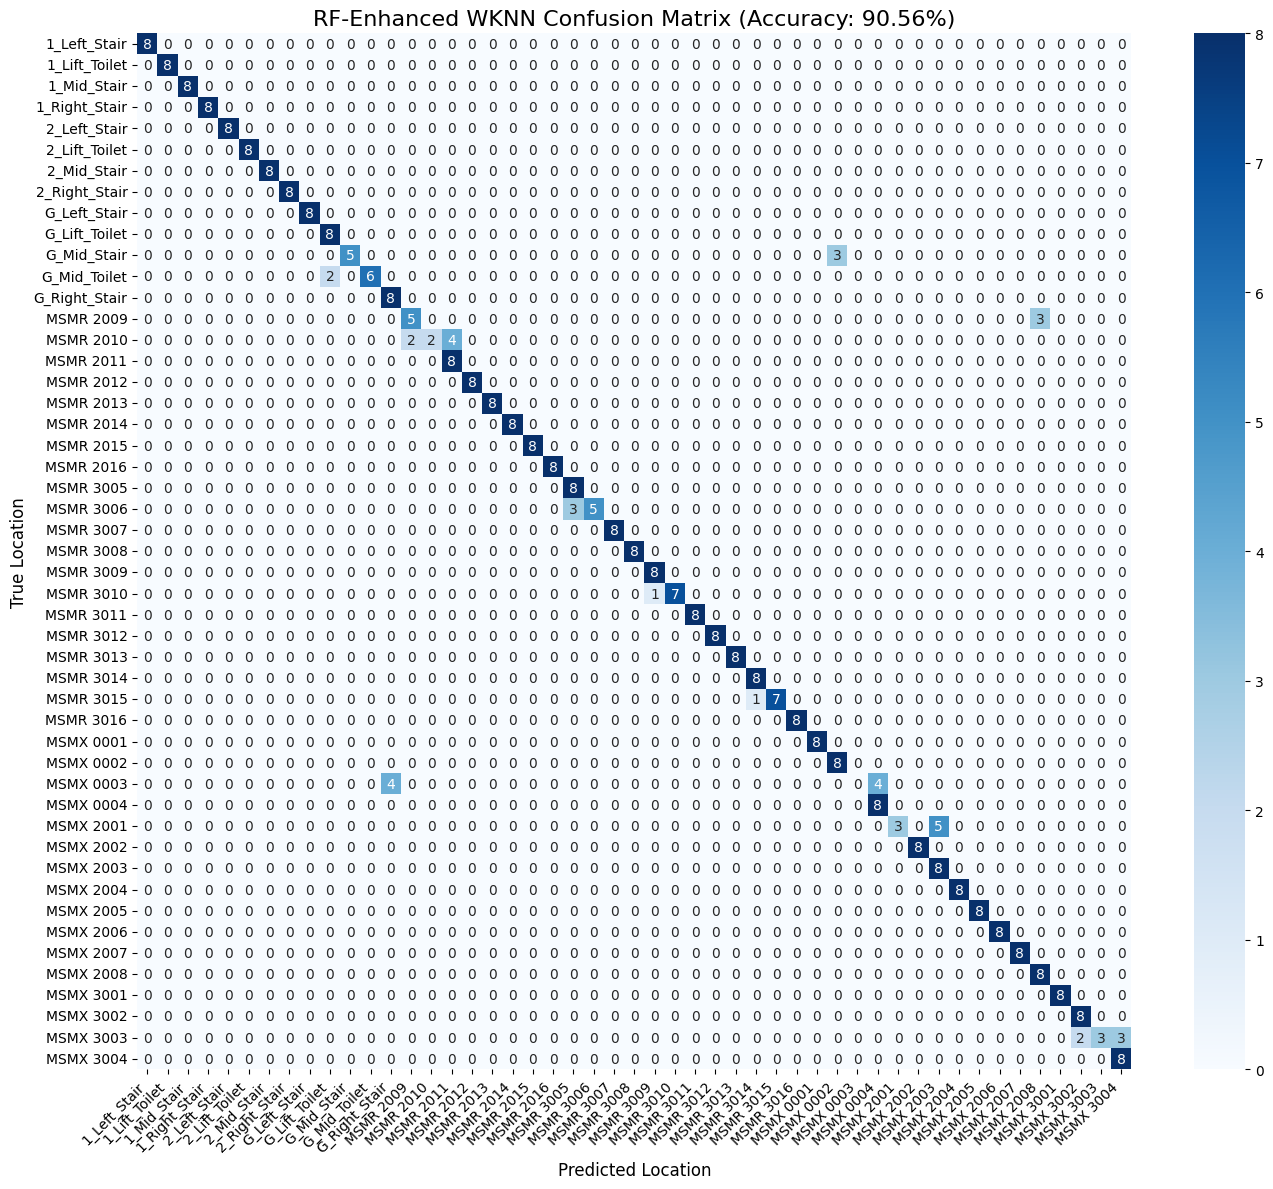

In [15]:
# ==========================================
# 4. Generate confusion matrix image for hybrid architecture
# ==========================================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating and saving confusion matrix for the hybrid model...")

# Extract classification labels from the WKNN model
classes = wknn.classes_

# Compute confusion matrix
cm_hybrid = confusion_matrix(y_test, y_pred, labels=classes)

# Set figure size
# Large enough to ensure clear visibility for 40+ room labels
plt.figure(figsize=(14, 12))

# Use blue color theme (Blues) to represent the hybrid architecture
# and differentiate it from the pure RF model
sns.heatmap(
    cm_hybrid,
    annot=True,      # Display actual values inside each cell
    fmt='d',         # Integer number format
    cmap='Blues',    # Blue gradient theme
    xticklabels=classes,
    yticklabels=classes
)

# Dynamically generate title with accuracy value
plt.title(
    f'RF-Enhanced WKNN Confusion Matrix (Accuracy: {accuracy * 100:.2f}%)',
    fontsize=16
)
plt.ylabel('True Location', fontsize=12)
plt.xlabel('Predicted Location', fontsize=12)

# Adjust tick label angles to prevent overlapping
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# Save high-resolution image
# 300 dpi is the standard resolution for academic publications
plt.savefig('Hybrid_Confusion_Matrix.png', dpi=300)

print("Confusion matrix successfully saved as 'Hybrid_Confusion_Matrix.png'.")

In [16]:
import joblib
# ==========================================
# 3. Seal and Packaging (Export)
# ==========================================
# Save the model
joblib.dump(wknn, 'pwise_wknn_model3.pkl')
# Extremely Important: Save the MAC address list of those 15 key access points!
# From now on, when your phone detects a signal, you must only extract these 15 signals and feed them to the model!
joblib.dump(top_aps, 'pwise_top150_features3.pkl')

print("\nCongratulations! The model has been successfully sealed to 'pwise_wknn_model3.pkl'")
print("The list of golden characteristics has been save to 'pwise_top15_features3.pkl'")


Congratulations! The model has been successfully sealed to 'pwise_wknn_model3.pkl'
The list of golden characteristics has been save to 'pwise_top15_features3.pkl'
